# Beşiktaş İlçesi En Kısa Yol Ödevi Raporu

## 1. Projenin Amacı ve Kapsamı
Projenin temel amacı; gerçek dünya coğrafi verilerini (**OpenStreetMap**) kullanarak dinamik bir ulaşım şebekesi modellemek ve bu şebeke üzerinde **Dijkstra En Kısa Yol Algoritması**'nın çalışma prensiplerini analitik olarak test etmektir. 

Analiz bölgesi olarak İstanbul'un en yoğun ve karmaşık yol ağlarından birine sahip olan **Beşiktaş ilçesi** seçilmiştir. Algoritmanın başarısını ve ağ topolojisinin etkilerini net bir şekilde görebilmek adına, ilçenin coğrafi olarak birbirine uzak iki uç noktası (Güneyde **Dolmabahçe Sarayı** ve Kuzeyde **4. Levent**) başlangıç ve bitiş rotası olarak belirlenmiştir.

---

## 2. Teorik Altyapı ve Graf Modellemesi
Projede, Beşiktaş yol şebekesi matematiksel olarak bir ağırlıklı graf $G = (V, E)$ yapısına dönüştürülmüştür:
* **Düğümler (Vertices - $V$):** Yol ağındaki tüm kavşaklar ve yol birleşim noktaları birer düğüm olarak tanımlanmıştır.
* **Ayrıtlar (Edges - $E$):** İki kavşağı birbirine bağlayan sokaklar, caddeler ve yaya yolları grafın ayrıtlarını oluşturmaktadır.
* **Ağırlık Fonksiyonu (Weight - $w(e)$):** Algoritmanın sadece adım sayısına (hop count) değil, gerçek fiziksel mesafeye odaklanması için her bir sokağın metre cinsinden uzunluğu ayrıt ağırlığı olarak atanmıştır.

---

## 3. Metodoloji ve Karşılaştırmalı Senaryolar
Çalışmanın derinliğini artırmak adına, ulaşım ağı tek bir tip yerine iki farklı şebeke modeli üzerinden asimetrik olarak incelenmiştir:

1.  **Araç Yolu Şebekesi (Drive Network - Yönlü Graf):**
    * Bu modelde graf, **Yönlü Graf (Directed Graph / Digraph)** olarak inşa edilmiştir.
    * Trafik kuralları, tek yönlü sokaklar ve girilemez caddeler ayrıtların yönünü ($uv \neq vu$) belirler. 
    * Dijkstra algoritması bu modelde yön kısıtlarına uymak zorunda olduğundan, rota zaman zaman uzamakta ve dolambaçlı hale gelmektedir.

2.  **Yaya Yolu Şebekesi (Walk Network - Yönsüz Graf):**
    * Bu modelde graf, **Yönsüz Graf (Undirected Graph)** mantığıyla ele alınmıştır.
    * Yayalar için tek yön kısıtlaması olmadığından bağlantılar çift yönlüdür ($uv = vu$). Ayrıca araçların giremediği dar sokaklar, merdivenler ve kestirmeler de ağa dahildir.
    * Dijkstra algoritması bu modelde topolojik kısıtlardan bağımsız olarak en optimal geometrik kestirmeleri bulabilmektedir.

---

## 4. Kullanılan Teknolojik Ekosistem
Projenin veritabanı altyapısı ve algoritmik çözümleri Python dilinde şu endüstri standardı kütüphanelerle uygulanmıştır:
* **OSMnx:** OpenStreetMap API'leri üzerinden Beşiktaş ilçesinin coğrafi koordinatlarını ve yol katmanlarını çekmek için kullanılmıştır.
* **NetworkX:** İndirilen coğrafi veriyi yönlü/yönsüz ağırlıklı graf objelerine çevirmek ve arka planda optimize edilmiş **Dijkstra** koşturan yerleşik fonksiyonları çalıştırmak için kullanılmıştır.
* **Matplotlib:** Ham graf yapısını ve algoritma tarafından hesaplanan en kısa rotaları harita üzerinde görselleştirmek amacıyla entegre edilmiştir.

---

## 5. Beklenen Çıktılar ve Analiz
Proje sonucunda; ham yol ağı haritası, ardından Dolmabahçe - 4. Levent arasında hesaplanan **En Kısa Araç Rotası** ve **En Kısa Yaya Rotası** ayrı ayrı görselleştirilmektedir. Şebeke kısıtlamaları (yönlülük/yönsüzlük) nedeniyle araç ve yaya yollarının metrik uzunlukları arasındaki fark analitik olarak ortaya konulmaktadır.

In [2]:
!pip install osmnx networkx matplotlib

In [3]:
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
# --- 1. Verileri Çekme ---
place = "Beşiktaş, İstanbul, Turkey"
print(f"'{place}' için graf verileri indiriliyor... Lütfen bekleyin.")

# Araç (Drive) ve Yaya (Walk) graflarını ayrı ayrı çekiyoruz
G_drive = ox.graph_from_place(place, network_type="drive")
G_walk = ox.graph_from_place(place, network_type="walk")

print("Graflar başarıyla indirildi.")

'Beşiktaş, İstanbul, Turkey' için graf verileri indiriliyor... Lütfen bekleyin.
Graflar başarıyla indirildi.


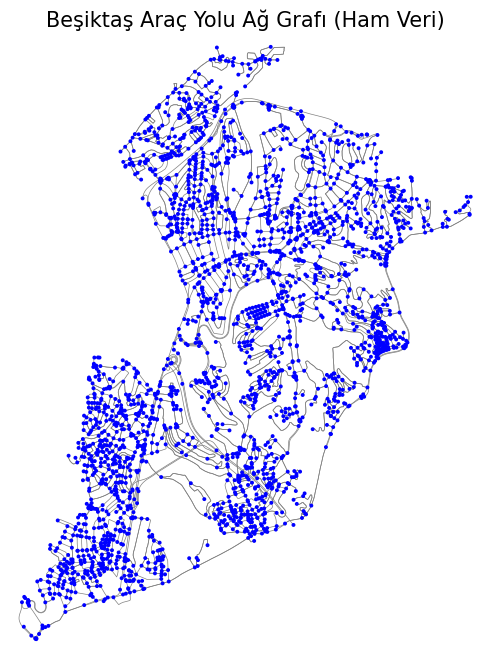

In [5]:
# --- Tüm Grafı (Sokaklar ve Kavşaklar) Ayrı Çizdirme ---
fig, ax = ox.plot_graph(
    G_drive, 
    node_size=8,        # Kavşak noktalarının boyutu
    node_color="blue",  # Kavşak renkleri
    edge_color="gray",  # Sokak çizgilerinin rengi
    edge_linewidth=0.5, 
    bgcolor="white",
    show=False,
    close=False
)
ax.set_title("Beşiktaş Araç Yolu Ağ Grafı (Ham Veri)", fontsize=15)
plt.show()


=== KARŞILAŞTIRMA SONUÇLARI ===
Araç Rotası Uzunluğu (Drive): 6603.61 metre
Yaya Rotası Uzunluğu (Walk):  6117.95 metre
Fark: 485.67 metre


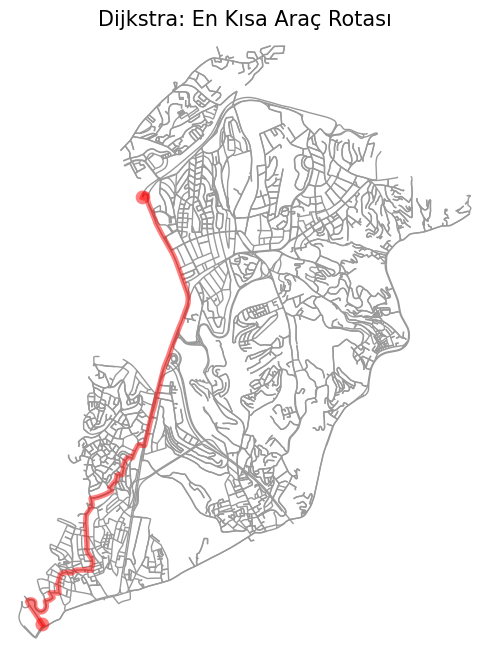

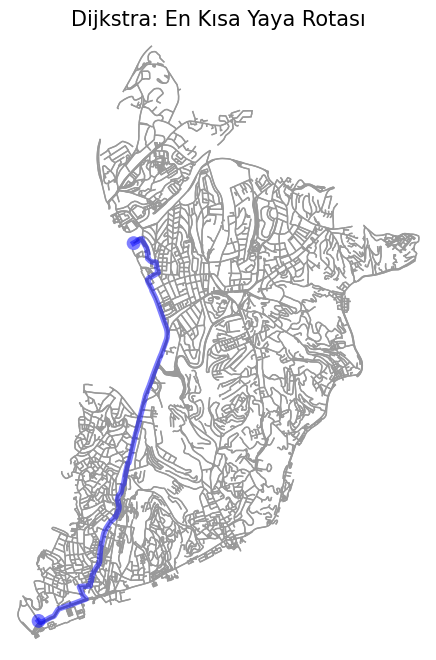

In [6]:
# --- 2. Başlangıç ve Bitiş Noktaları ---
# Beşiktaş Meydan civarından Yıldız Parkı/Ortaköy yönüne doğru rastgele iki koordinat
# Beşiktaş'ın iki uzak ucu: Dolmabahçe'den 4. Levent'e
start_latlng = (41.0390, 28.9950) # Başlangıç: Dolmabahçe Sarayı civarı
end_latlng = (41.0830, 29.0100)   # Bitiş: 4. Levent civarı

# Koordinatlara en yakın düğümleri (kavşakları) bulma (X=Boylam, Y=Enlem)
start_node_drive = ox.distance.nearest_nodes(G_drive, X=start_latlng[1], Y=start_latlng[0])
end_node_drive = ox.distance.nearest_nodes(G_drive, X=end_latlng[1], Y=end_latlng[0])

start_node_walk = ox.distance.nearest_nodes(G_walk, X=start_latlng[1], Y=start_latlng[0])
end_node_walk = ox.distance.nearest_nodes(G_walk, X=end_latlng[1], Y=end_latlng[0])

# --- 3. Dijkstra Algoritması ile En Kısa Yolu Hesaplama ---
# weight='length' parametresi, ayrıtların (edge) ağırlığı olarak sokağın metrik uzunluğunu almasını sağlar.
# Bu parametre verilmezse Dijkstra sadece kaç sokak geçildiğine (hop count) bakar.

# Araç rotası
route_drive = nx.shortest_path(G_drive, start_node_drive, end_node_drive, weight='length')
dist_drive = nx.shortest_path_length(G_drive, start_node_drive, end_node_drive, weight='length')

# Yaya rotası
route_walk = nx.shortest_path(G_walk, start_node_walk, end_node_walk, weight='length')
dist_walk = nx.shortest_path_length(G_walk, start_node_walk, end_node_walk, weight='length')

# --- 4. Karşılaştırma Sonuçları ---
print("\n=== KARŞILAŞTIRMA SONUÇLARI ===")
print(f"Araç Rotası Uzunluğu (Drive): {dist_drive:.2f} metre")
print(f"Yaya Rotası Uzunluğu (Walk):  {dist_walk:.2f} metre")
print(f"Fark: {abs(dist_drive - dist_walk):.2f} metre")

# --- 5. Görselleştirme ---
# Araç rotasını çizdirme (Kırmızı)
fig, ax = ox.plot_graph_route(
    G_drive, 
    route_drive, 
    route_color='red', 
    route_linewidth=4, 
    node_size=0, 
    bgcolor='white',
    show=False,  # Anında göstermeyi kapatıyoruz
    close=False  # Figürü arka planda kapatmayı engelliyoruz
)
ax.set_title("Dijkstra: En Kısa Araç Rotası", fontsize=15)
plt.show()

# Yaya rotasını çizdirme (Mavi)
fig, ax = ox.plot_graph_route(
    G_walk, 
    route_walk, 
    route_color='blue', 
    route_linewidth=4, 
    node_size=0, 
    bgcolor='white',
    show=False,
    close=False
)
ax.set_title("Dijkstra: En Kısa Yaya Rotası", fontsize=15)
plt.show()